In [ ]:
# Time Series Forecasting: Random Forest, XGBoost, and LSTM

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
import datetime

In [ ]:
# Load data
items = pd.read_csv("items.csv")
restaurants = pd.read_csv("resturants.csv")
sales = pd.read_csv("sales.csv")

In [ ]:
# Merge datasets
items = items.rename(columns={'id': 'item_id', 'store_id': 'restaurant_id'})
restaurants = restaurants.rename(columns={'id': 'restaurant_id', 'name': 'restaurant_name'})
sales_full = sales.merge(items, on='item_id').merge(restaurants, on='restaurant_id')
print(sales_full.columns)

Index(['date', 'item_id', 'price', 'item_count', 'restaurant_id', 'name',
       'kcal', 'cost', 'restaurant_name'],
      dtype='object')


In [ ]:
# Convert date to datetime
sales_full['date'] = pd.to_datetime(sales_full['date'])
sales_full = sales_full.sort_values('date')

Exploratory data analysis

In [ ]:
# Basic info
print("Items head:", items.shape, "| Restaurants head:", restaurants.shape, "| Sales head:", sales.shape)
print(f"Items: {items.head(1).values} | Restaurants: {restaurants.head(1).values} | Sales: {sales.head(1).values}")
print("Items:", items.head(1).to_dict(orient='records')[0],
      "| Restaurants:", restaurants.head(1).to_dict(orient='records')[0],
      "| Sales:", sales.head(1).to_dict(orient='records')[0])

Items head: (100, 5) | Restaurants head: (6, 2) | Sales head: (109600, 4)
Items: [[1 4 'Chocolate Cake' 554 6.71]] | Restaurants: [[1 "Bob's Diner"]] | Sales: [['2019-01-01' 3 29.22 2.0]]
Items: {'item_id': 1, 'restaurant_id': 4, 'name': 'Chocolate Cake', 'kcal': 554, 'cost': 6.71} | Restaurants: {'restaurant_id': 1, 'restaurant_name': "Bob's Diner"} | Sales: {'date': '2019-01-01', 'item_id': 3, 'price': 29.22, 'item_count': 2.0}


<Axes: xlabel='item_count', ylabel='Count'>

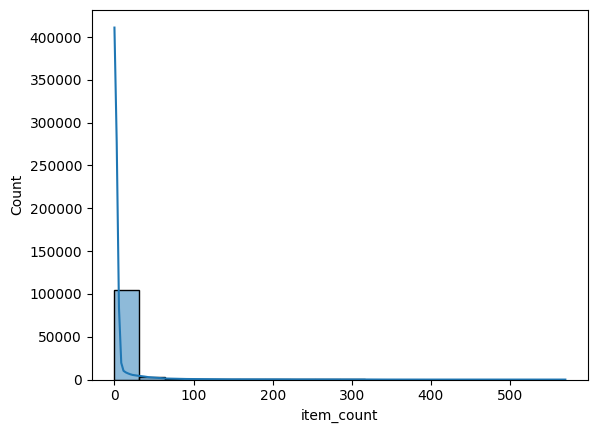

In [ ]:
# Distribution of item_count
sns.histplot(sales_full['item_count'], kde=True)

<Axes: title={'center': 'Average Daily Sales'}, xlabel='date'>

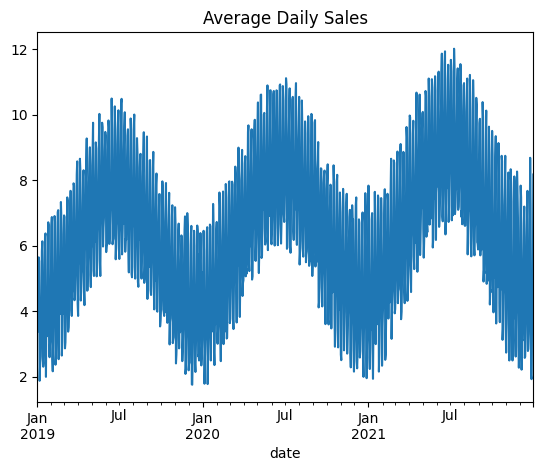

In [ ]:
# Average sales over time
sales_full.groupby('date')['item_count'].mean().plot(title="Average Daily Sales")

<Axes: title={'center': 'Total Sales by Restaurant'}, ylabel='restaurant_name'>

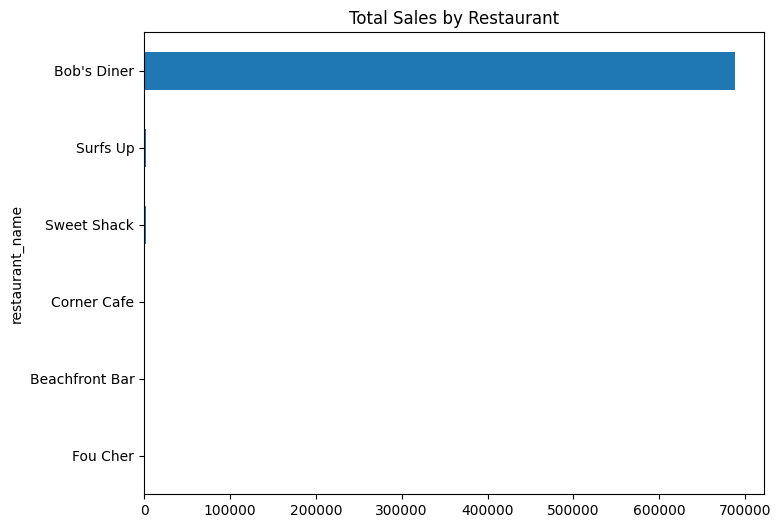

In [ ]:
# Sales by restaurant
sales_full.groupby('restaurant_name')['item_count'].sum().sort_values().plot(kind='barh', title="Total Sales by Restaurant", figsize=(8,6))

In [ ]:
# Remove outliers for EDA
# Remove row's where store_name is Bob's Diner

sales_full.drop(sales_full[sales_full['restaurant_name'] == 'Bob\'s Diner'].index, inplace=True)
sales_full.shape

(83296, 9)

<Axes: title={'center': 'Total Sales by Restaurant'}, ylabel='restaurant_name'>

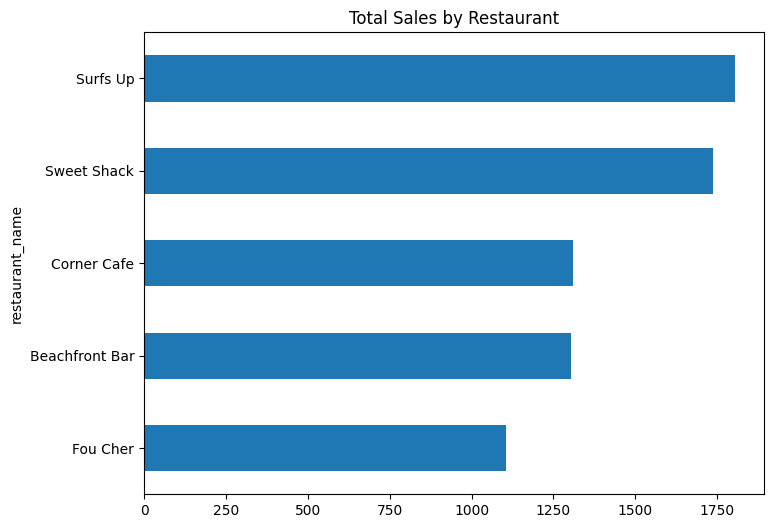

In [ ]:
# Sales by restaurant
sales_full.groupby('restaurant_name')['item_count'].sum().sort_values().plot(kind='barh', title="Total Sales by Restaurant", figsize=(8,6))

In [ ]:
# --- Exploratory Data Analysis (EDA) ---
print("\n🔍 EDA: Dataset Overview")
print(sales_full.info())


🔍 EDA: Dataset Overview
<class 'pandas.core.frame.DataFrame'>
Index: 83296 entries, 72 to 109599
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             83296 non-null  datetime64[ns]
 1   item_id          83296 non-null  int64         
 2   price            83296 non-null  float64       
 3   item_count       83296 non-null  float64       
 4   restaurant_id    83296 non-null  int64         
 5   name             83296 non-null  object        
 6   kcal             83296 non-null  int64         
 7   cost             83296 non-null  float64       
 8   restaurant_name  83296 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(3), object(2)
memory usage: 6.4+ MB
None


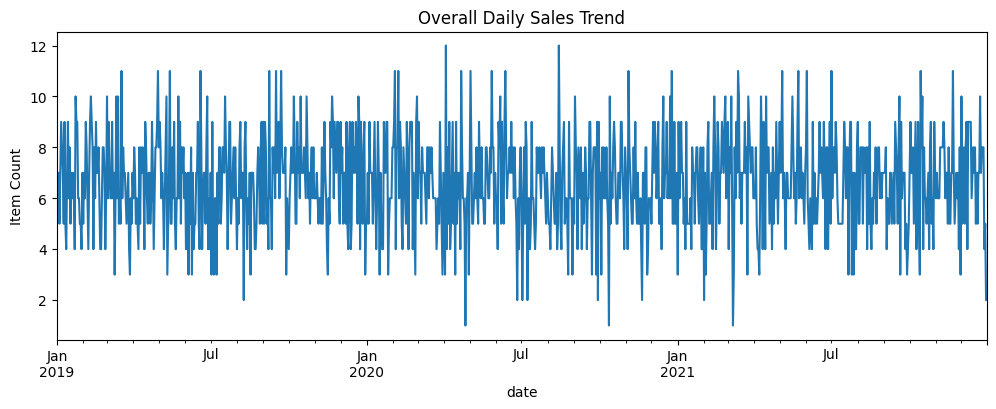

In [ ]:
# a. Overall sales pattern
sales_full.groupby('date')['item_count'].sum().plot(figsize=(12,4), title="Overall Daily Sales Trend")
plt.ylabel("Item Count")
plt.show()

In [ ]:
# Convert dataframe into time series

sales_full = sales_full.set_index('date')
sales_full.head(2)

,item_id,price,item_count,restaurant_id,name,kcal,cost,restaurant_name,weekday
date,,,,,,,,,
2019-01-01,66,6.31,0.0,4,Cherry Cake,586,6.31,Fou Cher,Tuesday
2019-01-01,65,20.02,0.0,4,Lamb with Bread and Vegetables Meal,724,20.02,Fou Cher,Tuesday


In [ ]:
sales_full = sales_full.sort_index()
sales_full['2019-01-01':'2019-01-07'].item_count.sum()

np.float64(49.0)

In [ ]:
sales_full.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 83296 entries, 2019-01-01 to 2021-12-31
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          83296 non-null  int64  
 1   price            83296 non-null  float64
 2   item_count       83296 non-null  float64
 3   restaurant_id    83296 non-null  int64  
 4   name             83296 non-null  object 
 5   kcal             83296 non-null  int64  
 6   cost             83296 non-null  float64
 7   restaurant_name  83296 non-null  object 
 8   weekday          83296 non-null  object 
dtypes: float64(3), int64(3), object(3)
memory usage: 8.4+ MB


In [ ]:
# Index dataframe
sales_full.index

DatetimeIndex(['2019-01-01', '2019-01-01', '2019-01-01', '2019-01-01',
               '2019-01-01', '2019-01-01', '2019-01-01', '2019-01-01',
               '2019-01-01', '2019-01-01',
               ...
               '2021-12-31', '2021-12-31', '2021-12-31', '2021-12-31',
               '2021-12-31', '2021-12-31', '2021-12-31', '2021-12-31',
               '2021-12-31', '2021-12-31'],
              dtype='datetime64[ns]', name='date', length=83296, freq=None)

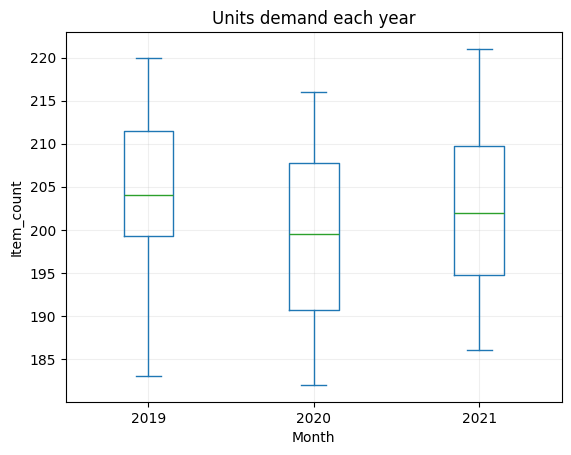

In [ ]:
# Group by month and year

sales_full['year'] = sales_full.index.year
sales_full.groupby([sales_full.index.month, 'year'])['item_count'].sum().unstack().plot.box()
plt.xlabel('Month')
plt.ylabel('Item_count')
plt.title('Units demand each year')
plt.grid(which='both', alpha=0.2)
plt.show()



*   Median unit demand has decreased over the years from 204 to 203.
*   Overall spread of demand has increased leading to lower revenues overall.



([<matplotlib.axis.XTick at 0x7d3dae188fd0>,
 [Text(0, 0, 'Mon'),
  Text(1, 0, 'Tue'),
  Text(2, 0, 'Wed'),
  Text(3, 0, 'Thu'),
  Text(4, 0, 'Fri'),
  Text(5, 0, 'Sat'),
  Text(6, 0, 'Sun')])

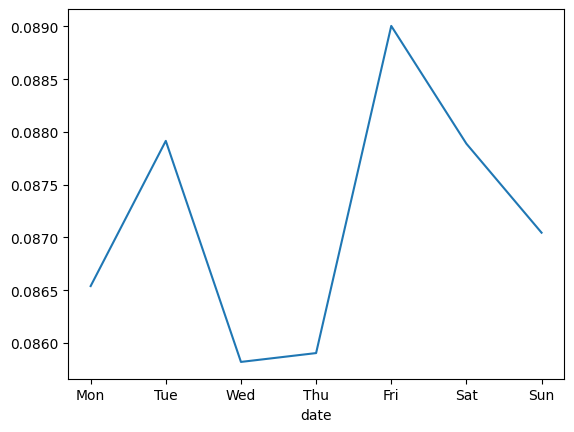

In [ ]:
# b. Sales by day of the week
sales_full.groupby(sales_full.index.dayofweek)['item_count'].mean().plot()
plt.xticks([0,1,2,3,4,5,6], ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])



*   Highest average sales recorded on Tuesdays, Fridays and Saturdays whereas lower sales happen on Mondays, Wednesdays, Thursdays and Sundays.



([<matplotlib.axis.XTick at 0x7d3dae024910>,
 [Text(1, 0, 'Jan'),
  Text(2, 0, 'Feb'),
  Text(3, 0, 'Mar'),
  Text(4, 0, 'Apr'),
  Text(5, 0, 'May'),
  Text(6, 0, 'Jun'),
  Text(7, 0, 'Jul'),
  Text(8, 0, 'Aug'),
  Text(9, 0, 'Sep'),
  Text(10, 0, 'Oct'),
  Text(11, 0, 'Nov'),
  Text(12, 0, 'Dec')])

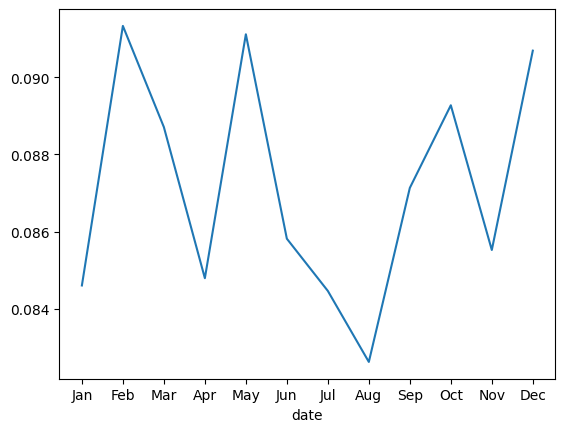

In [ ]:
# c. Monthly sales trends
sales_full.groupby(sales_full.index.month)['item_count'].mean().plot()
plt.xticks([1,2,3,4,5,6,7,8,9,10,11,12], ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])



*   Averagely sales are up and down every month wwith few spikes in February, May, October and December..



([<matplotlib.axis.XTick at 0x7d3dadff0d10>,
 [Text(1, 0, 'Q1'), Text(2, 0, 'Q2'), Text(3, 0, 'Q3'), Text(4, 0, 'Q4')])

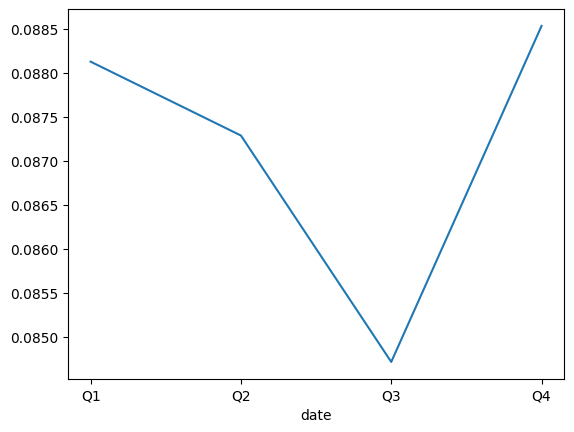

In [ ]:
# d. Sales by quarter
sales_full.groupby(sales_full.index.quarter)['item_count'].mean().plot()
plt.xticks([1,2,3,4], ['Q1', 'Q2', 'Q3', 'Q4'])



*   On an average, quarter 3 was the lowest in terms of sales, quarter 4 and 1 being doing good followed by a dropping quarter 2.
*   Overall, July, August and Septemeber are the worst performing months.

<Axes: xlabel='restaurant_name'>

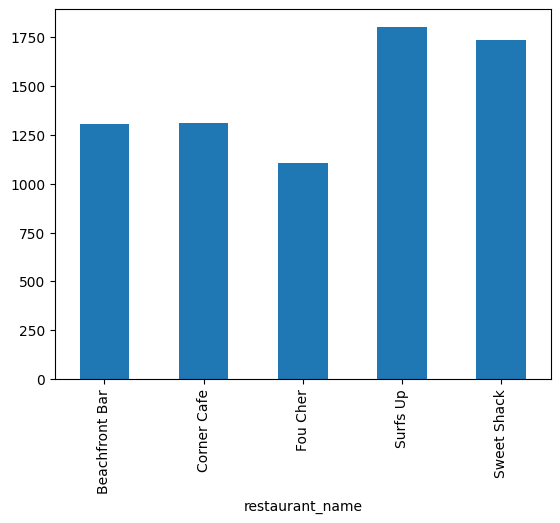

In [ ]:
# Compare the performances of the different restaurants.
## Find out which restaurant had the most sales and
## look at the sales for each restaurant across different years, months, and days.

sales_full.groupby('restaurant_name')['item_count'].sum().plot(kind='bar')



*   Surfs up's sales are followed by Sweet Shack and Corner Cafe.



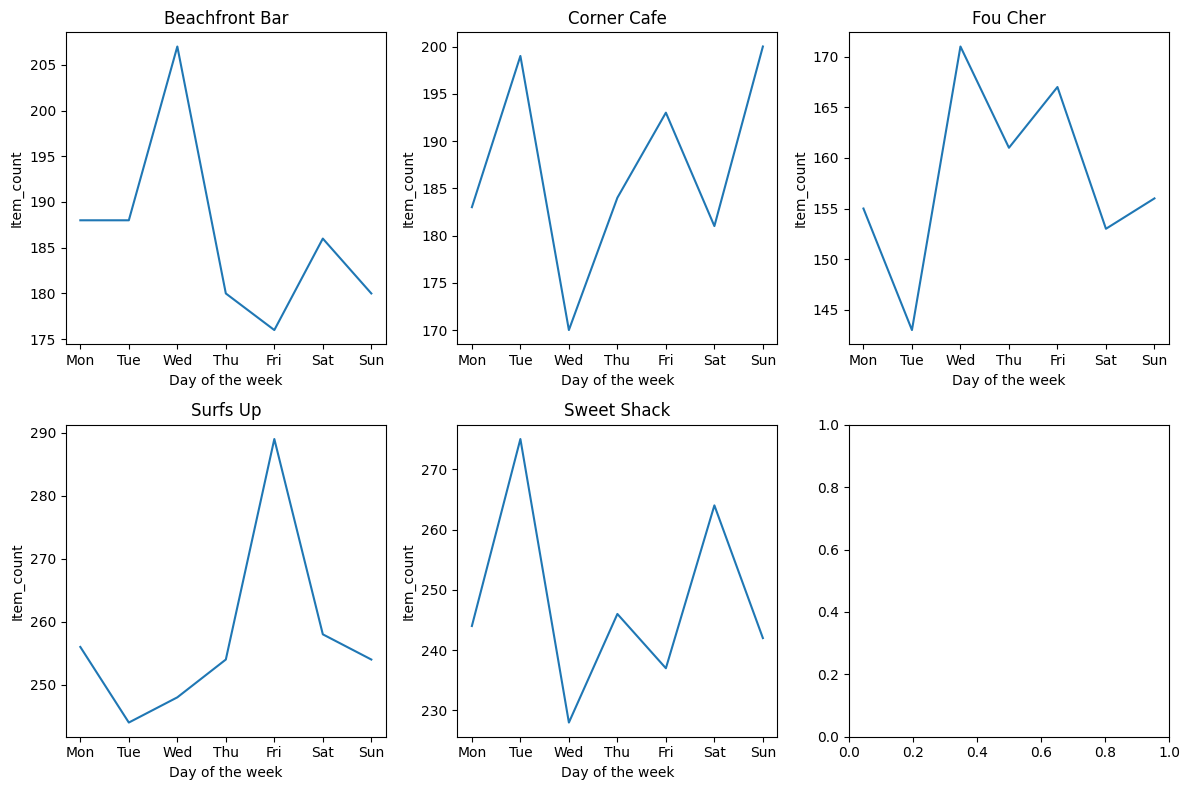

In [ ]:
# e. Find out how sales fluctuate across different days of the week for different restaurants

BB_df = sales_full[sales_full['restaurant_name'] == 'Beachfront Bar']
CC_df = sales_full[sales_full['restaurant_name'] == 'Corner Cafe']
FC_df = sales_full[sales_full['restaurant_name'] == 'Fou Cher']
SU_df = sales_full[sales_full['restaurant_name'] == 'Surfs Up']
SS_df = sales_full[sales_full['restaurant_name'] == 'Sweet Shack']

fig, axs = plt.subplots(2,3, figsize=(12,8))

# Define store dataframes and subplot axes
store_dfs = [BB_df, CC_df, FC_df, SU_df, SS_df]
axes = axs.flatten()

# Titles for the subplots
titles = ['Beachfront Bar', 'Corner Cafe', 'Fou Cher', 'Surfs Up', 'Sweet Shack']


for df, ax, title in zip(store_dfs, axes, titles):
    df.groupby(df.index.dayofweek)['item_count'].sum().plot(ax=ax)
    ax.set_xticks(range(7))
    ax.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
    ax.set_title(title)
    ax.set_xlabel('Day of the week')
    ax.set_ylabel('Item_count')

# Adjust layout
plt.tight_layout()
plt.show()



1.   Sales have increased sharply on tuesday for Corner Cafe and Sweet Shack whereas it declined heavily for Fou Cher and Surfs Up.
2.   Similarly, on wedenesdays, the sales shoot up for Beachfront Bar, Fou Cher, whereas declined for Corner Cafe and Sweet Shack.
3.   Thursday, Friday and Saturday were reasonably consistent for Fou Cher, whereas sales for Surfs Up and Corner cafe shooted high on friday.
4.   On weekend, it dipped for all except for sweet shack.


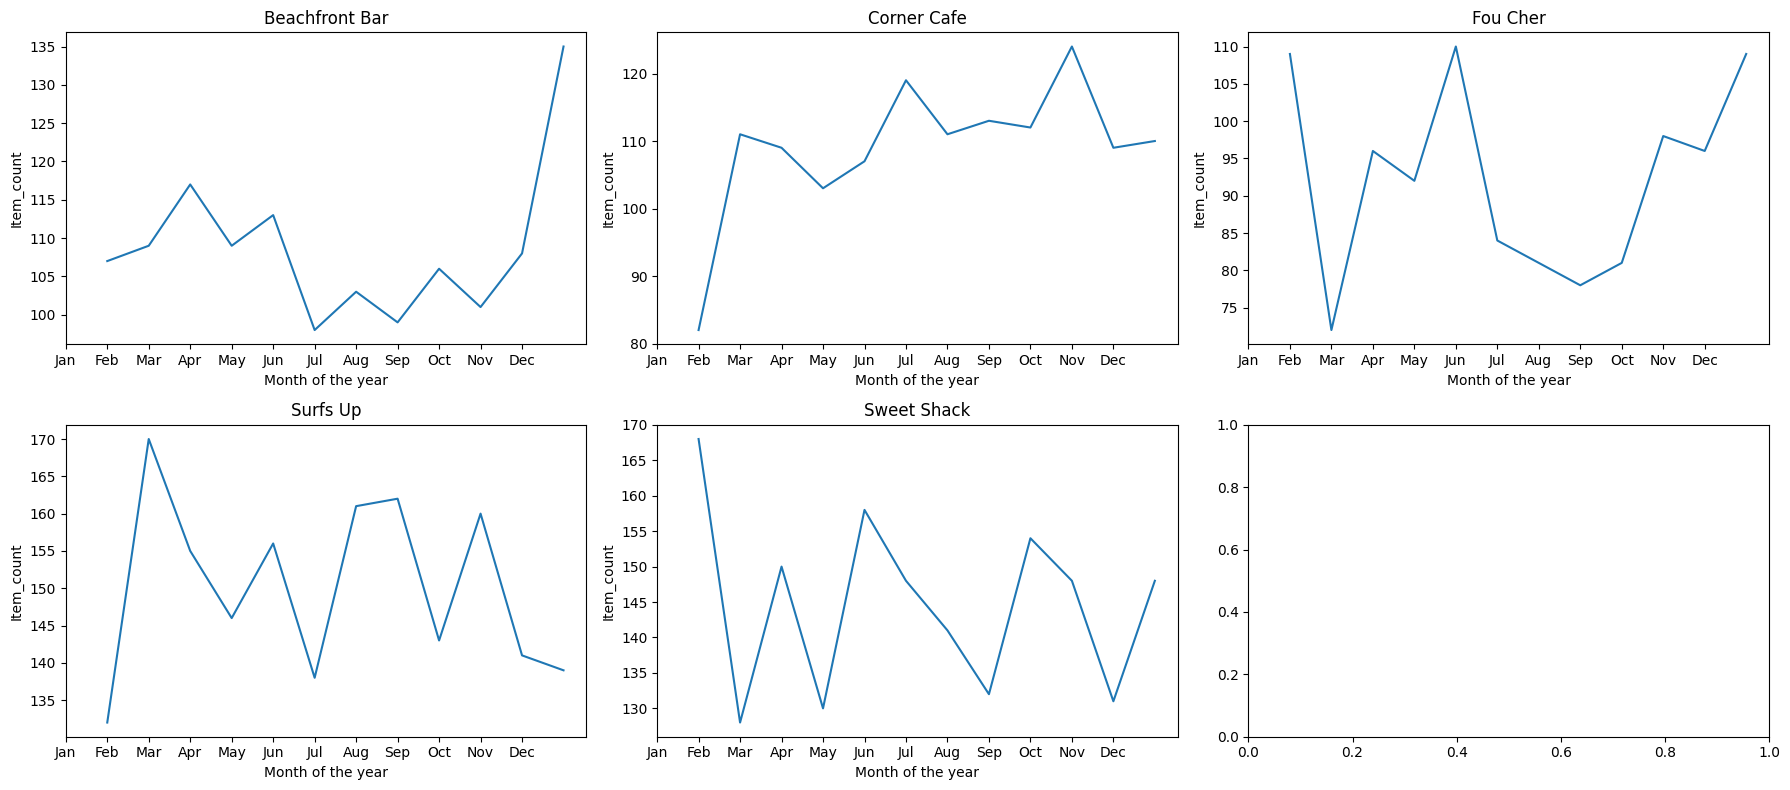

In [ ]:
# Find out how sales fluctuate across different months of the year for different restaurants

BB_df = sales_full[sales_full['restaurant_name'] == 'Beachfront Bar']
CC_df = sales_full[sales_full['restaurant_name'] == 'Corner Cafe']
FC_df = sales_full[sales_full['restaurant_name'] == 'Fou Cher']
SU_df = sales_full[sales_full['restaurant_name'] == 'Surfs Up']
SS_df = sales_full[sales_full['restaurant_name'] == 'Sweet Shack']

fig, axs = plt.subplots(2,3, figsize=(18,8))

# Define store dataframes and subplot axes
store_dfs = [BB_df, CC_df, FC_df, SU_df, SS_df]
axes = axs.flatten()

# Titles for the subplots
titles = ['Beachfront Bar', 'Corner Cafe', 'Fou Cher', 'Surfs Up', 'Sweet Shack']


for df, ax, title in zip(store_dfs, axes, titles):
    df.groupby(df.index.month)['item_count'].sum().plot(ax=ax)
    ax.set_xticks(range(12))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_title(title)
    ax.set_xlabel('Month of the year')
    ax.set_ylabel('Item_count')

# Adjust layout
plt.tight_layout()
plt.show()



1.   No similar patterns or trends among different restaurants. Beachfront Bar's revenues have decresed consistenly from beginning of the year towards the end. On the opposite, Corner Cafe's revenues have increased from the beginning of the year towards the end.
2.   Fou Cher, Surfs up and Sweet Shack's revenues have been flucutating all over the year.


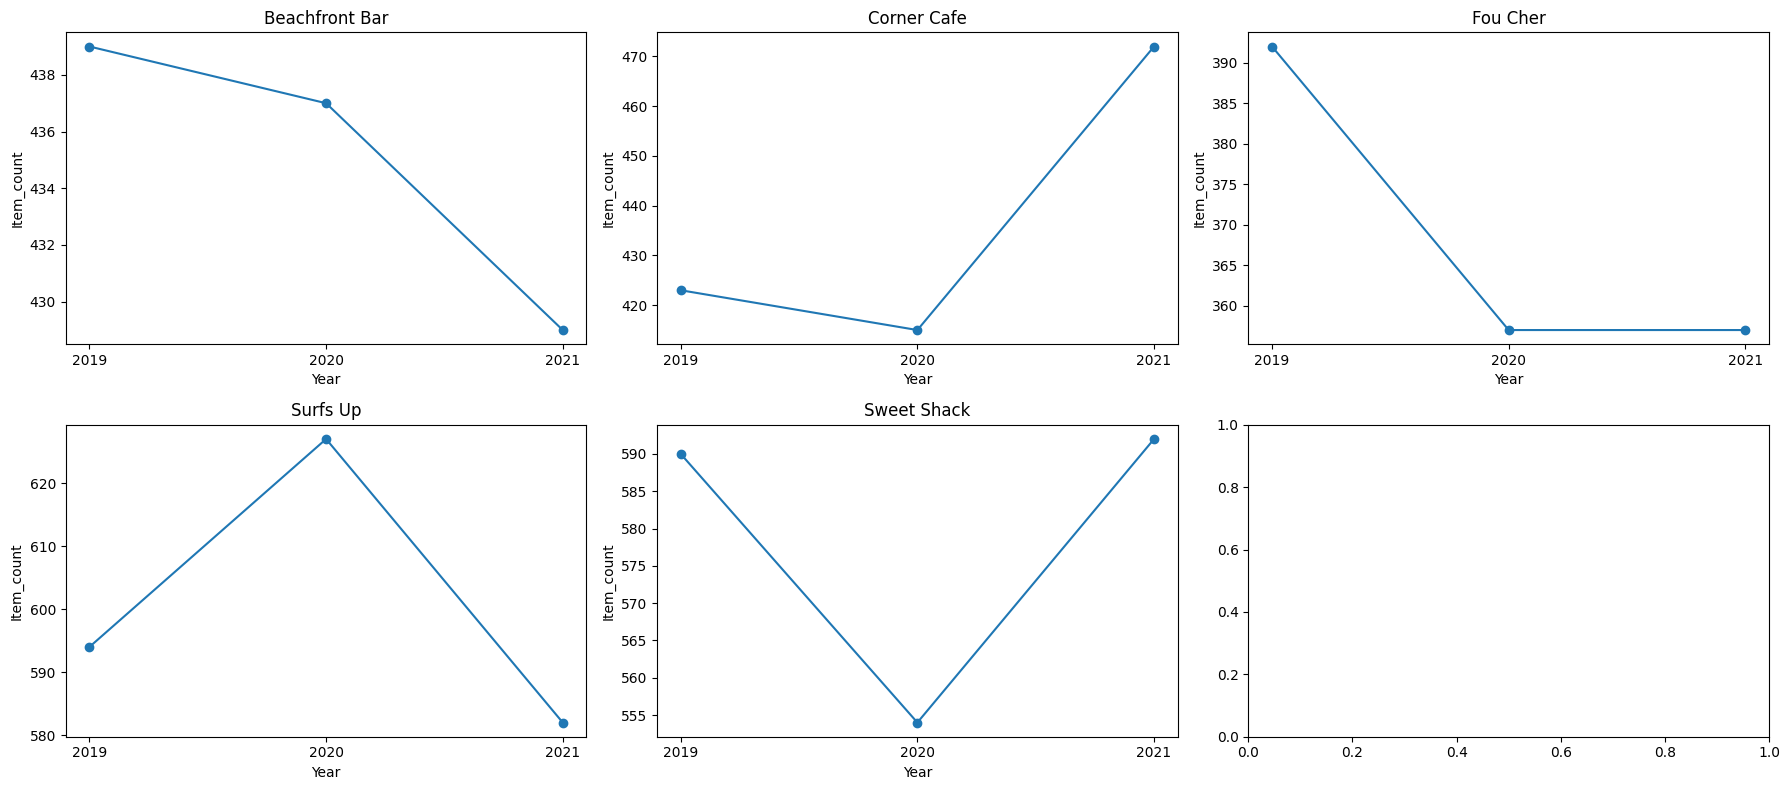

In [ ]:
# Find out how sales fluctuate across different years for different restaurants

BB_df = sales_full[sales_full['restaurant_name'] == 'Beachfront Bar']
CC_df = sales_full[sales_full['restaurant_name'] == 'Corner Cafe']
FC_df = sales_full[sales_full['restaurant_name'] == 'Fou Cher']
SU_df = sales_full[sales_full['restaurant_name'] == 'Surfs Up']
SS_df = sales_full[sales_full['restaurant_name'] == 'Sweet Shack']

fig, axs = plt.subplots(2,3, figsize=(18,8))

# Define store dataframes and subplot axes
store_dfs = [BB_df, CC_df, FC_df, SU_df, SS_df]
axes = axs.flatten()

# Titles for the subplots
titles = ['Beachfront Bar', 'Corner Cafe', 'Fou Cher', 'Surfs Up', 'Sweet Shack']


for df, ax, title in zip(store_dfs, axes, titles):
    annual_revenue = df.groupby(df.index.year)['item_count'].sum()
    annual_revenue.plot(ax=ax, marker='o')
    ax.set_xticks(annual_revenue.index)
    ax.set_xticklabels(annual_revenue.index)
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('Item_count')

# Adjust layout
plt.tight_layout()
plt.show()



1.   2019: Higher sales - Beachfront Bar, Fou Cher and Sweet Shack
2.   2020: Higher sales - Surfs Up. Declining sales - Beachfront Bar.
3.   2021: Higher sales - Corner Cafe and Sweet Shack
4.   Overall - Beachfront Bar, Fou cher and Surfs Up's sales have declined.



In [ ]:
# Identify the most popular items overall and the stores where they are being sold. Also, find out the most popular item at each store

items_summary = {
    'Beachfront Bar': BB_df.groupby('name')['item_count'].sum(),
    'Corner Cafe': CC_df.groupby('name')['item_count'].sum(),
    'Fou Cher': FC_df.groupby('name')['item_count'].sum(),
    'Surfs Up': SU_df.groupby('name')['item_count'].sum(),
    'Sweet Shack': SS_df.groupby('name')['item_count'].sum()
}

items_summary_df = pd.DataFrame(items_summary)
items_summary_df

,Beachfront Bar,Corner Cafe,Fou Cher,Surfs Up,Sweet Shack
name,,,,,
Amazing Cocktail,NaN,NaN,NaN,91.0,NaN
Amazing Lamb Dinner,NaN,NaN,52.0,NaN,NaN
Amazing Sweet Breaded Carrot Cake,NaN,2.0,NaN,NaN,NaN
Amazing Trout with Vegetables Dinner,NaN,NaN,NaN,36.0,NaN
Amazing Vegetable and Bread Dinner,NaN,NaN,1.0,NaN,NaN
...,...,...,...,...,...
Steak Meal,NaN,NaN,NaN,135.0,NaN
Super Sweet Cocktail,NaN,NaN,12.0,NaN,NaN
Sweet Savory Cake,NaN,NaN,25.0,NaN,NaN


In [ ]:
# f. Popular items overall and at each store
most_popular_items = {
    store: df.idxmax() for store, df in items_summary.items()
}

most_popular_items_df = pd.DataFrame(list(most_popular_items.items()), columns = ['Store', 'Most Popular Item'])

combined_items = pd.concat(items_summary.values(), axis=1).sum(axis=1)

top_10_items = combined_items.nlargest(10)

top_10_items_df = top_10_items.reset_index()
top_10_items_df.columns = ['Item Name', 'Total Count']

print('\nMost Popular Items by Store:')
print(most_popular_items_df)
print('\nTop 10 Items:')
print(top_10_items_df)


Most Popular Items by Store:
            Store              Most Popular Item
0  Beachfront Bar        Fantastic Milky Smoothy
1     Corner Cafe           Frozen Milky Smoothy
2        Fou Cher  Blue Ribbon Fruity Vegi Lunch
3        Surfs Up             Awesome Soft Drink
4     Sweet Shack                Awesome Smoothy

Top 10 Items:
                                           Item Name  Total Count
0                                    Awesome Smoothy       1692.0
1                            Fantastic Milky Smoothy       1165.0
2                                 Awesome Soft Drink        997.0
3                      Blue Ribbon Fruity Vegi Lunch        298.0
4                               Frozen Milky Smoothy        273.0
5                             Lamb with Bread Entree        172.0
6                                Roast Mutton Entree        165.0
7                  Blue Ribbon Lamb with Rolls Lunch        161.0
8                                Oysters Rockefeller        157.0
9

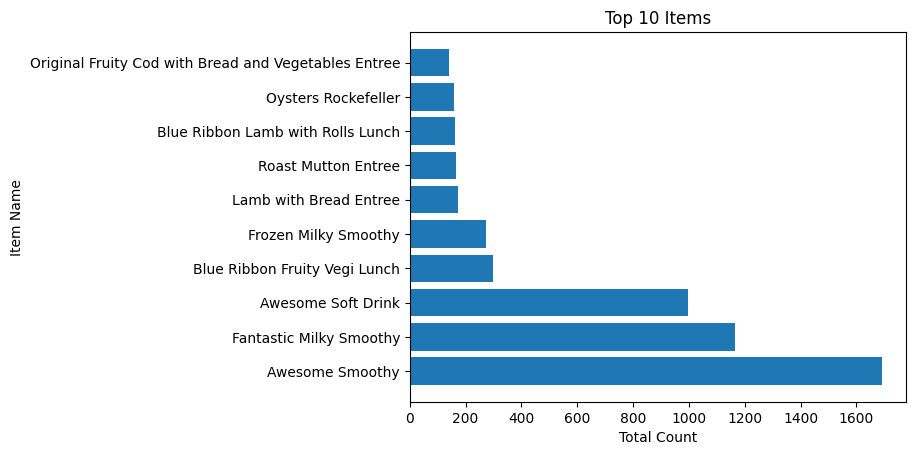

In [ ]:
plt.barh(top_10_items_df['Item Name'], top_10_items_df['Total Count'])
plt.xlabel('Total Count')
plt.ylabel('Item Name')
plt.title('Top 10 Items')
plt.show()

Top 3 items: Awesome smoothy by Sweet Shack, Fantastic Milk Smoothy by Beachfront Bar and Awesome soft drink by Surfs Up.

In [ ]:
# g. Store with most sales vs most revenue
sales_full['revenue'] = sales_full['item_count'] * sales_full['price']
revenue_per_store = sales_full.groupby('restaurant_name').agg({'item_count':'sum', 'revenue':'sum'})
revenue_per_store['revenue_per_item'] = revenue_per_store['revenue'] / revenue_per_store['item_count']
print("\nRevenue per Store:")
print(revenue_per_store.sort_values(by='revenue', ascending=False))


Revenue per Store:
                 item_count   revenue  revenue_per_item
restaurant_name                                        
Fou Cher             1106.0  27885.37         25.212812
Corner Cafe          1310.0  16551.43         12.634679
Surfs Up             1803.0  15651.49          8.680804
Beachfront Bar       1305.0   3796.20          2.908966
Sweet Shack          1736.0   2578.27          1.485179


In [ ]:
# h. Most expensive item per restaurant and their calorie count
expensive_items = sales_full.sort_values(['restaurant_name', 'price'], ascending=[True, False])
most_expensive_per_store = expensive_items.drop_duplicates('restaurant_name', keep='first')
print("\nMost Expensive Item per Restaurant:")
print(most_expensive_per_store[['restaurant_name', 'name', 'price', 'kcal']])


Most Expensive Item per Restaurant:
           restaurant_name                           name  price  kcal
date                                                                  
2019-01-01  Beachfront Bar          Sweet Vegi Soft Drink   5.70   538
2019-01-01     Corner Cafe                     Pike Lunch  26.37   653
2019-01-01        Fou Cher  Blue Ribbon Fruity Vegi Lunch  53.98   881
2019-01-01        Surfs Up                     Steak Meal  26.21   607
2019-01-01     Sweet Shack  Blue Ribbon Frozen Milky Cake   7.70   636


In [ ]:
# Feature engineering
sales_full['day'] = sales_full.index.day
sales_full['month'] = sales_full.index.month
sales_full['year'] = sales_full.index.year
sales_full['weekday'] = sales_full.index.day_name()
sales_full['is_weekend'] = sales_full['weekday'].isin(['Saturday', 'Sunday'])

In [ ]:
# Encode categorical columns
le_item = LabelEncoder()
le_rest = LabelEncoder()
le_weekday = LabelEncoder()
sales_full['item_name'] = le_item.fit_transform(sales_full['name'])
sales_full['restaurant_name'] = le_rest.fit_transform(sales_full['restaurant_name'])
sales_full['weekday'] = le_weekday.fit_transform(sales_full['weekday'])

# Target and features
target = 'item_count'
features = ['price', 'cost', 'kcal', 'month', 'day', 'weekday', 'is_weekend', 'item_name', 'restaurant_name']

In [ ]:
# Train-test split based on time
train = sales_full[sales_full.index < '2021-01-01']
test = sales_full[sales_full.index >= '2021-01-01']

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

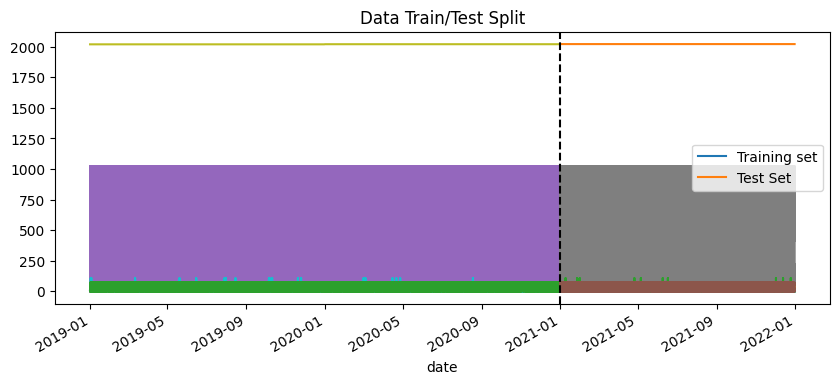

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
train.plot(ax=ax, label='Training set', title = 'Data Train/Test Split')
test.plot(ax=ax, label='Test set')
ax.axvline('2021-01-01', color='black', ls='--')
ax.legend(['Training set', 'Test Set'])
plt.show()

In [ ]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# --- XGBoost ---
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [ ]:
# --- LSTM Preparation ---
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(sales_full[features])
y_scaled = scaler_y.fit_transform(sales_full[[target]])

seq_len = 14
gen = TimeseriesGenerator(X_scaled, y_scaled, length=seq_len, batch_size=32)

In [ ]:
# LSTM Model
model = Sequential()
model.add(LSTM(64, activation='relu', input_shape=(seq_len, X_scaled.shape[1]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.fit(gen, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2603/2603 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - loss: 0.0042
Epoch 2/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0026
Epoch 3/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0022
Epoch 4/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0021
Epoch 5/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0021
Epoch 6/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0020
Epoch 7/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0020
Epoch 8/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0019
Epoch 9/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0020
Epoch 10/10
2603/2603 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0019


In [ ]:
# Predict with LSTM on test data
test_start_idx = len(X_scaled) - len(test) - seq_len
test_seq = X_scaled[test_start_idx:]
test_y_seq = y_scaled[test_start_idx:]
test_gen = TimeseriesGenerator(test_seq, test_y_seq, length=seq_len, batch_size=1)
lstm_preds_scaled = model.predict(test_gen)
lstm_preds = scaler_y.inverse_transform(lstm_preds_scaled).flatten()

27740/27740 ━━━━━━━━━━━━━━━━━━━━ 60s 2ms/step


In [ ]:
# Evaluate models
def evaluate(y_true, y_pred, model_name):
    print(f"\n{model_name} Results:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")
evaluate(y_test[-len(lstm_preds):], lstm_preds, "LSTM")


Random Forest Results:
MAE: 0.11439545782263878
RMSE: 0.3098098295688447
R2: 0.27347843188706134

XGBoost Results:
MAE: 0.10605778139719606
RMSE: 0.2874038457451134
R2: 0.37476500740367813

LSTM Results:
MAE: 0.06351824737026034
RMSE: 0.23990406475081516
R2: 0.5643543932616275


* On average, the LSTM predictions are ~0.06 units away from the actual sales — much more accurate than the others.
* LSTM is significantly better at reducing large errors — indicating it may be capturing patterns like seasonality or sequences better.
* LSTM explains 56.4% of the variance in sales, outperforming XGBoost (37.5%) and Random Forest (27.3%).
* LSTM model is clearly outperforming the tree-based models in this multivariate time series setup — likely because it's able to capture temporal dependencies, sequential trends, and lags in a way the others can't.

<ipython-input-1-a49f207da993>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MAE', data=df_metrics, palette='crest')
<ipython-input-1-a49f207da993>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='RMSE', data=df_metrics, palette='flare')
<ipython-input-1-a49f207da993>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2', data=df_metrics, palette='viridis')


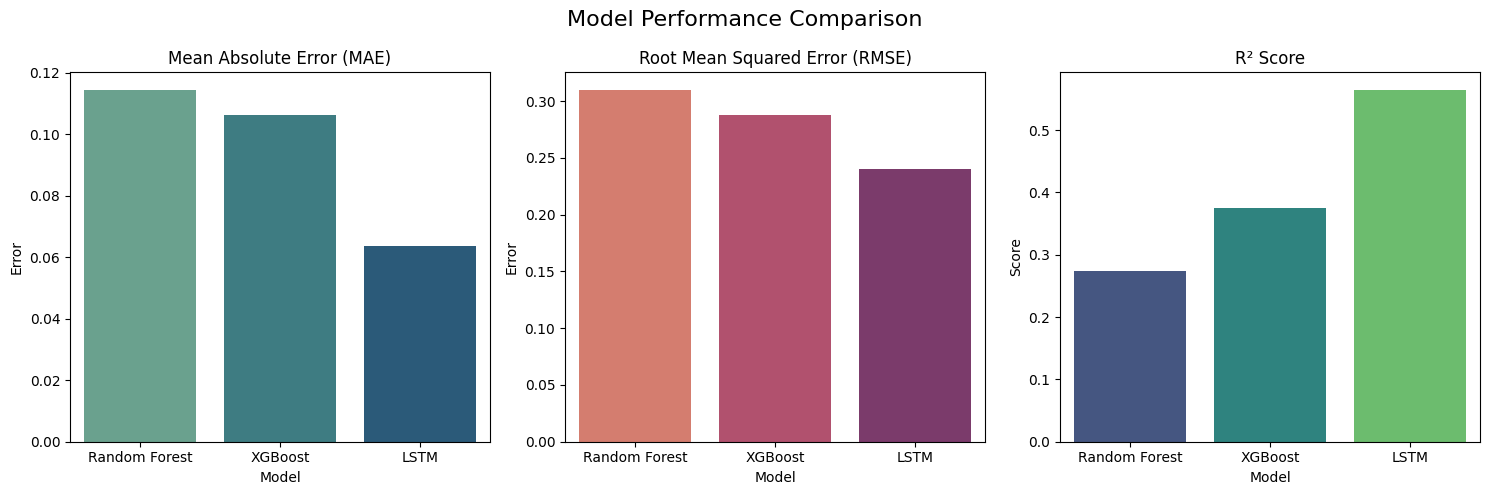

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Evaluation metric values
metrics = {
    'Model': ['Random Forest', 'XGBoost', 'LSTM'],
    'MAE': [0.1144, 0.1061, 0.0635],
    'RMSE': [0.3098, 0.2874, 0.2399],
    'R2': [0.2735, 0.3748, 0.5644]
}

# Convert to DataFrame for plotting
df_metrics = pd.DataFrame(metrics)

# Plotting
plt.figure(figsize=(15, 5))

# MAE plot
plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='MAE', data=df_metrics, palette='crest')
plt.title('Mean Absolute Error (MAE)')
plt.ylabel('Error')

# RMSE plot
plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='RMSE', data=df_metrics, palette='flare')
plt.title('Root Mean Squared Error (RMSE)')
plt.ylabel('Error')

# R2 Score plot
plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='R2', data=df_metrics, palette='viridis')
plt.title('R² Score')
plt.ylabel('Score')

plt.suptitle("Model Performance Comparison", fontsize=16)
plt.tight_layout()
plt.show()

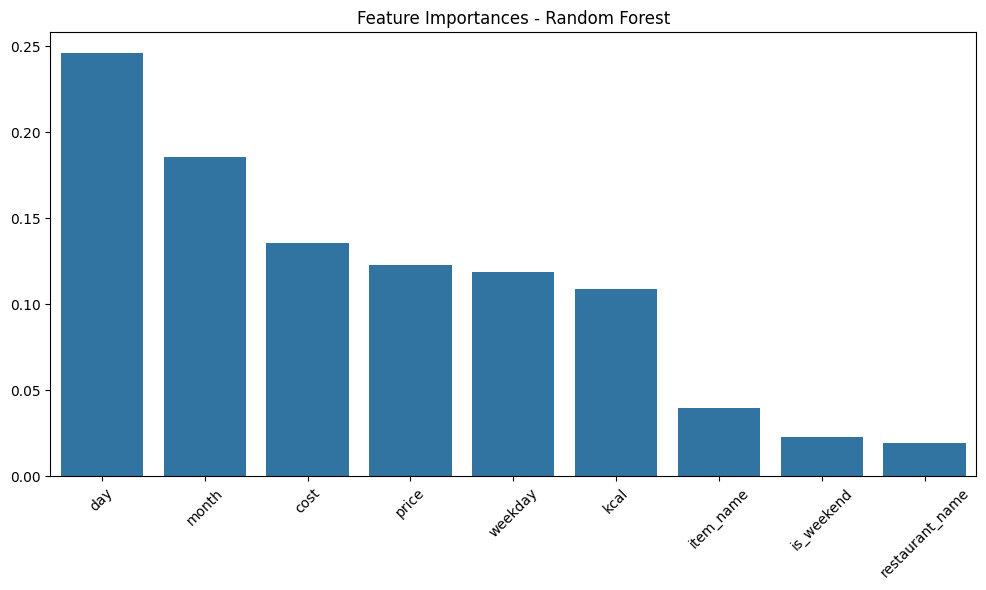

In [ ]:
# Feature importance
plt.figure(figsize=(10,6))
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title("Feature Importances - Random Forest")
sns.barplot(x=[features[i] for i in indices], y=importances[indices])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

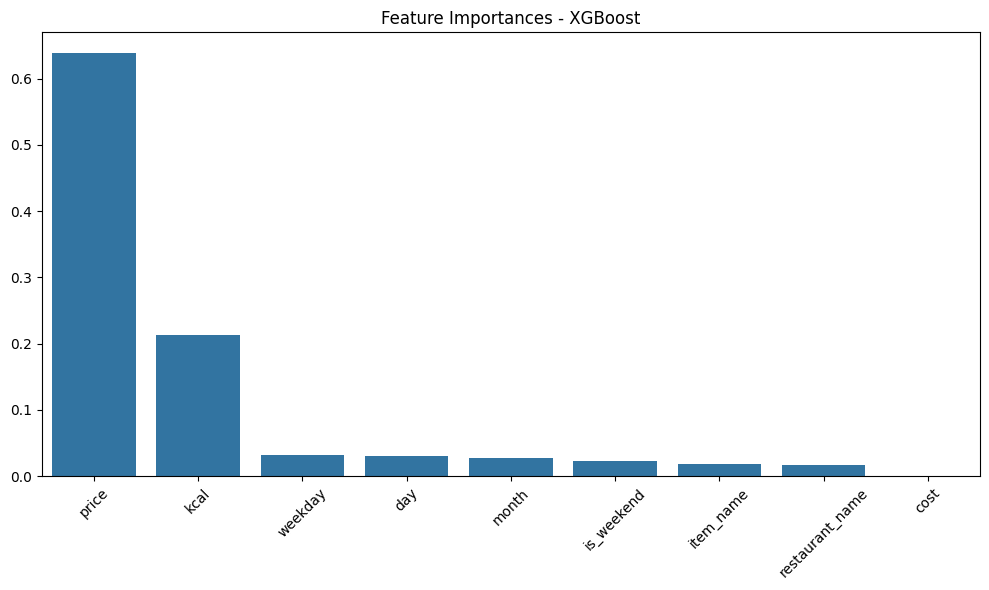

In [ ]:
plt.figure(figsize=(10,6))
xgb_importances = xgb.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]
plt.title("Feature Importances - XGBoost")
sns.barplot(x=[features[i] for i in xgb_indices], y=xgb_importances[xgb_indices])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

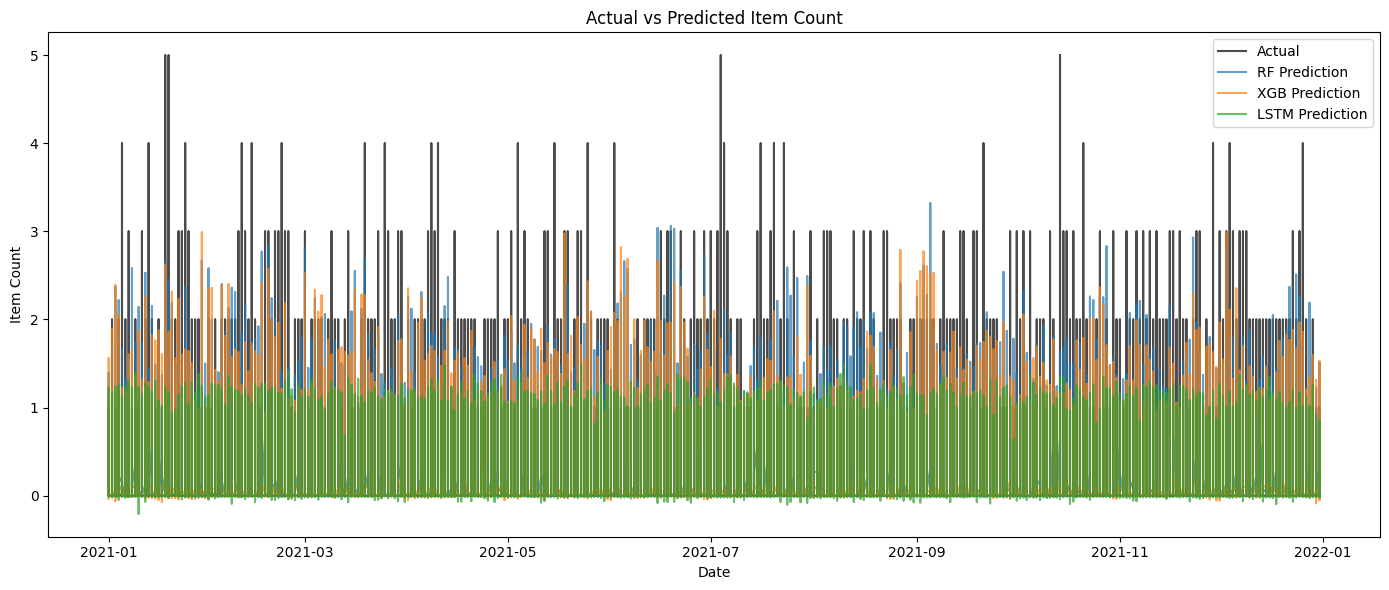

In [ ]:
# Comparison plot
plt.figure(figsize=(14,6))
plt.plot(test.index, y_test.values, label='Actual', color='black', alpha=0.7)
plt.plot(test.index, y_pred_rf, label='RF Prediction', alpha=0.7)
plt.plot(test.index, y_pred_xgb, label='XGB Prediction', alpha=0.7)
plt.plot(test.index[-len(lstm_preds):], lstm_preds, label='LSTM Prediction', alpha=0.7)
plt.title("Actual vs Predicted Item Count")
plt.xlabel("Date")
plt.ylabel("Item Count")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(len(y_test), len(y_pred_rf), len(y_pred_xgb), len(lstm_preds))
print(results_df.shape)

27740 27740 27740 27740
(27740, 3)


In [ ]:
# Restore date from index
results_df = test.copy()
results_df = results_df.reset_index()  # Brings 'date' back as a column from the index

# Add predictions
results_df['actual'] = y_test.reset_index(drop=True)
results_df['rf_pred'] = y_pred_rf
results_df['xgb_pred'] = y_pred_xgb
results_df['lstm_pred'] = lstm_preds

# Keep only relevant columns
results_df = results_df[['date', 'actual', 'rf_pred', 'xgb_pred', 'lstm_pred']]

# Export to CSV
results_df.to_csv("model_predictions_comparison.csv", index=False)
print("✅ Exported to 'model_predictions_comparison.csv'")

✅ Exported to 'model_predictions_comparison.csv'
